# Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import itertools
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Load Datasets

In [10]:
data_groups = {}


try:
    
    baseline_df = pd.read_csv('datasets/BaseDataset.csv')
    
    X = baseline_df.drop('Diabetes_012', axis=1)
    y = baseline_df['Diabetes_012']

    # 70/10/20 Split using random seed 42
    X_train_b, X_temp, y_train_b, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)
    
    # Reconstruct into dataframes so it matches the format of our other files
    data_groups['baseline'] = {
        'train': pd.concat([X_train_b, y_train_b], axis=1),
        'val': pd.concat([X_val_b, y_val_b], axis=1),
        'test': pd.concat([X_test_b, y_test_b], axis=1)
    }
    print("Baseline dataset loaded and split successfully!")
except FileNotFoundError:
    print("Baseline dataset not found. Please check the file path.")

# Load the PRE-BALANCED Datasets 
get_path = lambda split, samp, k: (
    f"datasets/{samp}/Smote" + ("" if split == "training" else f"_{split.capitalize()}") + f"_k{k}.csv"
    if samp == "oversampling" else
    f"datasets/{samp}/undersampling_" + ("train" if split == "training" else split) + f"_k{k}.csv"
)

file_paths = {
    f"{split}_{samp}_{k}": get_path(split, samp, k)
    for split, samp, k in itertools.product(["training", "test", "val"], ["oversampling", "undersampling"], [9, 12])
}

load_csv = lambda path: pd.read_csv(path) if os.path.exists(path) else None
datasets = {name: load_csv(path) for name, path in file_paths.items()}
datasets = {name: df for name, df in datasets.items() if df is not None}

print(f"Successfully loaded {len(datasets)} balanced dataset files!")

# Group them up
for samp, k in itertools.product(["oversampling", "undersampling"], [9, 12]):
    group_name = f"{samp}_{k}"
    try:
        data_groups[group_name] = {
            'train': datasets[f'training_{group_name}'],
            'val': datasets[f'val_{group_name}'],
            'test': datasets[f'test_{group_name}']
        }
    except KeyError:
        print(f"Missing files for {group_name}")

Baseline dataset loaded and split successfully!
Successfully loaded 12 balanced dataset files!


# KNN Evaluation

In [11]:
def process_and_evaluate_knn(group_name, data_dict):

    print(f"PROCESSING DATASET GROUP: {group_name.upper()}")
    
    # 1. Extract X and y from the pre-split dataframes
    X_train = data_dict['train'].drop('Diabetes_012', axis=1)
    y_train = data_dict['train']['Diabetes_012']
    
    X_val = data_dict['val'].drop('Diabetes_012', axis=1)
    y_val = data_dict['val']['Diabetes_012']
    
    X_test = data_dict['test'].drop('Diabetes_012', axis=1)
    y_test = data_dict['test']['Diabetes_012']

    # 2. Scale the features (Crucial for KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # 3. Hyperparameter Tuning on Validation Set
    print("Tuning KNN hyperparameters...")
    best_f1 = -1
    best_knn = None
    
    # Testing the required k values and metrics
    for k in [3, 5, 11, 21, 25, 31, 37]:
        for metric in ['euclidean', 'manhattan']:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(X_train_scaled, y_train)
            val_preds = knn.predict(X_val_scaled)
            
            # Using Macro F1 for tuning due to original class imbalance
            macro_f1 = f1_score(y_val, val_preds, average='macro')
            
            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_knn = knn
                
    print(f"Best Params Found: {best_knn.get_params()}")
    
    # 4. Save the best model
    model_filename = f'knn_{group_name}_model.pkl'
    joblib.dump(best_knn, model_filename)
    print(f"Model saved as '{model_filename}'")

    # 5. Final Evaluation on Test Set
    print(f"\nFinal Test Results for {group_name}")
    test_preds = best_knn.predict(X_test_scaled)
    
    print(f"Accuracy:    {accuracy_score(y_test, test_preds):.4f}")
    print(f"F1 Micro:    {f1_score(y_test, test_preds, average='micro'):.4f}")
    print(f"F1 Macro:    {f1_score(y_test, test_preds, average='macro'):.4f}")
    print(f"F1 Weighted: {f1_score(y_test, test_preds, average='weighted'):.4f}\n")
    
    # 6. Plot Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diab.', 'PreDiab.', 'Diabetes'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'KNN Confusion Matrix: {group_name}')
    plt.show()

# Execute Pipeline

PROCESSING DATASET GROUP: BASELINE
Tuning KNN hyperparameters...
Best Params Found: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Model saved as 'knn_baseline_model.pkl'

Final Test Results for baseline
Accuracy:    0.8219
F1 Micro:    0.8219
F1 Macro:    0.4016
F1 Weighted: 0.7993



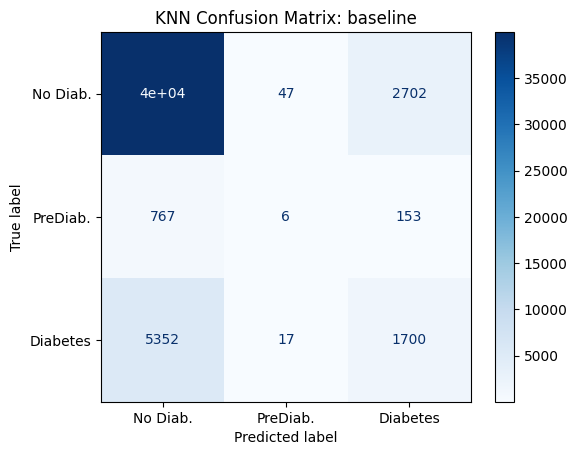

PROCESSING DATASET GROUP: OVERSAMPLING_9
Tuning KNN hyperparameters...
Best Params Found: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 25, 'p': 2, 'weights': 'uniform'}
Model saved as 'knn_oversampling_9_model.pkl'

Final Test Results for oversampling_9
Accuracy:    0.7317
F1 Micro:    0.7317
F1 Macro:    0.4280
F1 Weighted: 0.7597



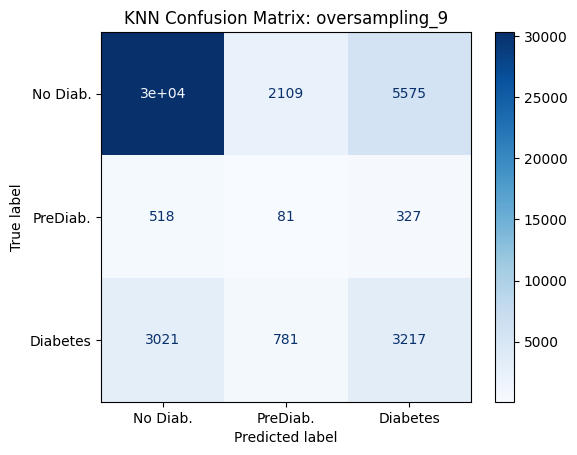

PROCESSING DATASET GROUP: OVERSAMPLING_12
Tuning KNN hyperparameters...
Best Params Found: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 37, 'p': 2, 'weights': 'uniform'}
Model saved as 'knn_oversampling_12_model.pkl'

Final Test Results for oversampling_12
Accuracy:    0.7325
F1 Micro:    0.7325
F1 Macro:    0.4321
F1 Weighted: 0.7613



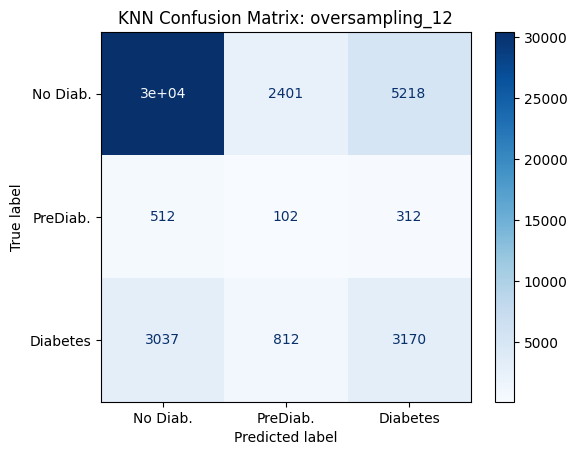

PROCESSING DATASET GROUP: UNDERSAMPLING_9
Tuning KNN hyperparameters...
Best Params Found: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 37, 'p': 2, 'weights': 'uniform'}
Model saved as 'knn_undersampling_9_model.pkl'

Final Test Results for undersampling_9
Accuracy:    0.5870
F1 Micro:    0.5870
F1 Macro:    0.4020
F1 Weighted: 0.6714



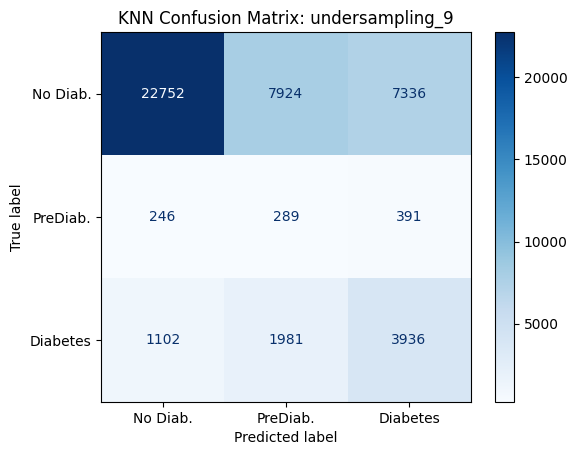

PROCESSING DATASET GROUP: UNDERSAMPLING_12
Tuning KNN hyperparameters...
Best Params Found: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 37, 'p': 2, 'weights': 'uniform'}
Model saved as 'knn_undersampling_12_model.pkl'

Final Test Results for undersampling_12
Accuracy:    0.5908
F1 Micro:    0.5908
F1 Macro:    0.4017
F1 Weighted: 0.6735



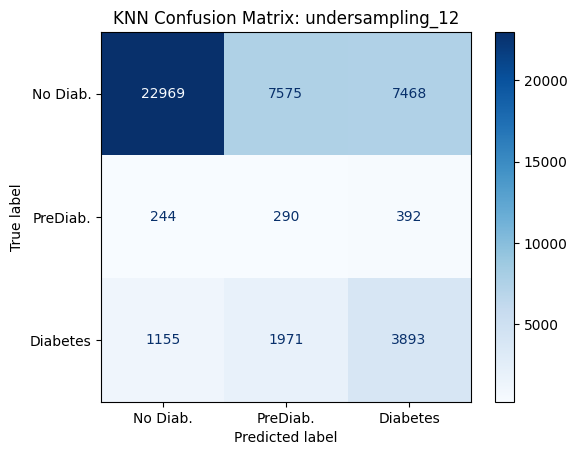

In [12]:
if not data_groups:
    print("No complete data groups found to process.")
else:
    for name, data_dict in data_groups.items():
        process_and_evaluate_knn(name, data_dict)